In [2]:
# IMPORTING LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

In [3]:
# LOAD THE DATASET

from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

EXPLORATORY DATA ANALYSIS

In [4]:
# BASIC STATISTICS OF THE DATA

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nSummary Statistics:")
print(df.describe())
print("\nClass Distribution:")
print(df['species'].value_counts())

Dataset Shape: (150, 6)

First 5 Rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

Summary Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.10

VISUALISATION

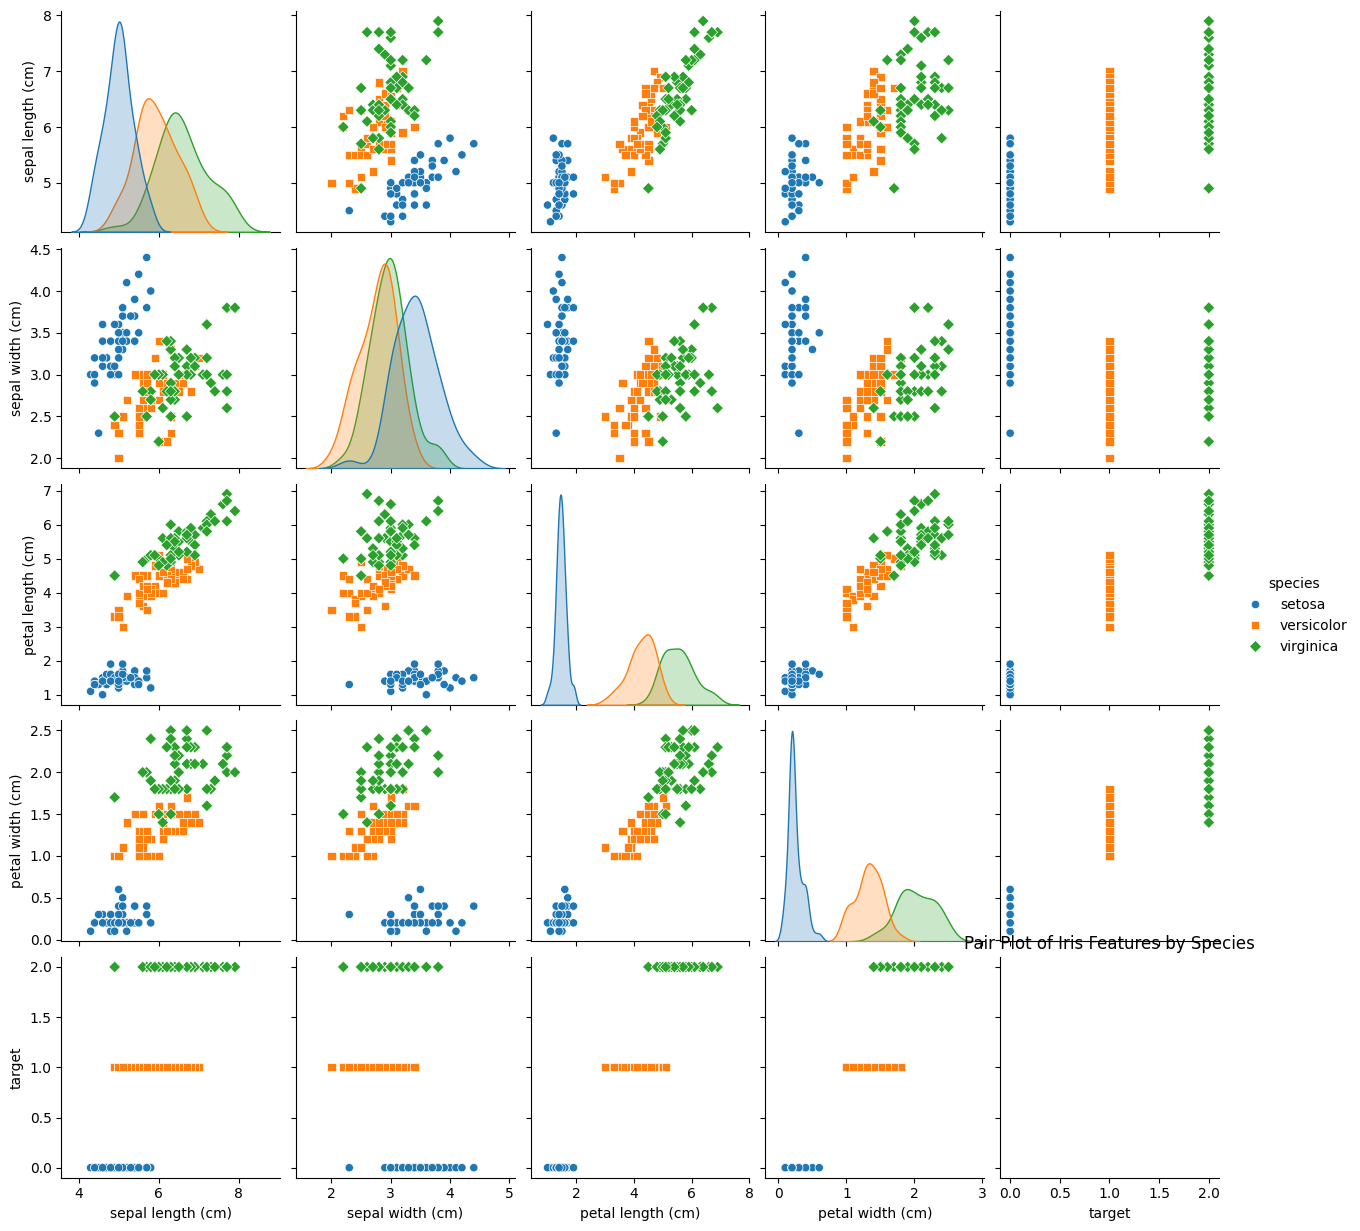

In [5]:
# PAIR PLOT

sns.pairplot(df, hue='species', markers=['o', 's', 'D'])
plt.title("Pair Plot of Iris Features by Species")
plt.show()

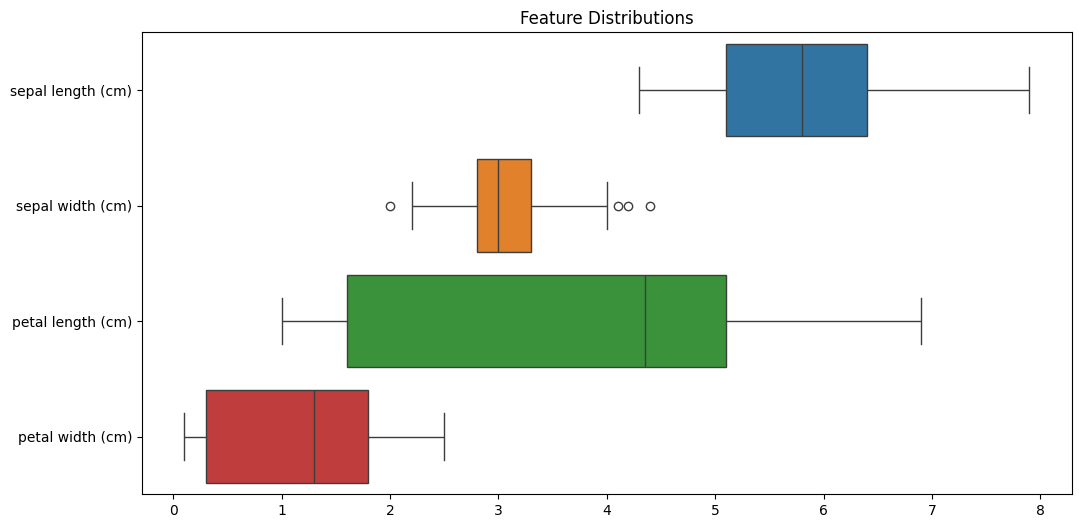

In [6]:
# BOX PLOT

plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns=['target']), orient='h')
plt.title("Feature Distributions")
plt.show()

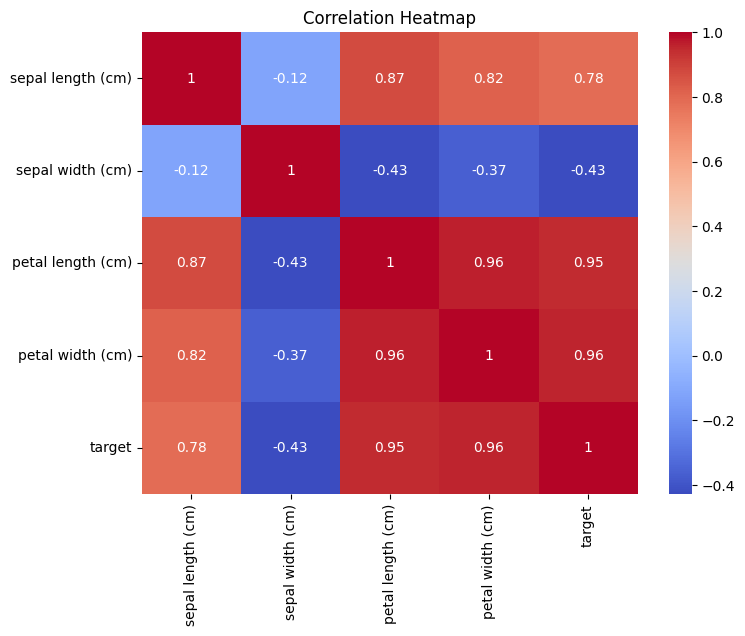

In [8]:
# CORRELATION HEATMAP

plt.figure(figsize=(8, 6))
# Exclude the non-numeric 'species' column before calculating correlation
# You can either drop it or select only numeric columns
sns.heatmap(df.drop(columns=['species']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

DATA PREPROCESSING

In [10]:
# SEPARATE FEATURES AND TARGET

iris = load_iris()
X, y = iris.data, iris.target

#X = df.drop(columns=['target','species'])
#y = df['target']
'''
X = df.drop(columns=['target', 'species'])
y = df['target']'''

"\nX = df.drop(columns=['target', 'species'])\ny = df['target']"

In [11]:
# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")

Train Shape: (120, 4), Test Shape: (30, 4)


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MODEL TRAINING AND EVALUATION

In [13]:
# 1. K-Nearest Neighbors(KNN)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("KNN Results:")
print(classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

KNN Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [14]:
# SUPPORT VECTOR MACHINE(SVM)

svm = SVC(kernel='linear', C=1.0)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

print("SVM Results:")
print(classification_report(y_test, y_pred_svm))

SVM Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



In [15]:
# RANDOM FOREST

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



MODEL COMPARISON

In [21]:
# MODEL COMPARISON

models = {
    'KNN': knn,
    'SVM': svm,
    'Random Forest': rf
}

# Store accuracies in a dictionary to easily find the model name later
accuracies = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies[name] = accuracy # Store accuracy with model name as key
    print(f"{name} Accuracy: {accuracy:.4f}")


KNN Accuracy: 1.0000
SVM Accuracy: 0.9667
Random Forest Accuracy: 1.0000


In [22]:
# BEST MODEL

# best_model = models[np.argmax(accuracy)]
# print(f"The best-performing model is: {best_model}")

best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]

print(f"The best-performing model is: {best_model_name}")

The best-performing model is: KNN


In [19]:
# hyperparameter tuning

# grid search for SVM

from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid = GridSearchCV(SVC(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Score:", grid.best_score_)

Best Parameters: {'C': 10, 'kernel': 'linear'}
Best Cross-Validation Score: 0.9583333333333334


In [20]:
def predict_iris(sepal_length, sepal_width, petal_length, petal_width):
    features = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    features_scaled = scaler.transform(features)
    prediction = svm.predict(features_scaled)
    return iris.target_names[prediction][0]

# Example Usage
print(predict_iris(5.1, 3.5, 1.4, 0.2))  # Output: 'setosa'

setosa
